In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from qnmsc.mpl_config import um, inv_um, mm
%matplotlib inline
%config InlineBackend.figure_format='retina'

if __name__=="__main__":
  import qnmsc.mpl_config
  qnmsc.mpl_config.config()
  DEBUG=False
  domain = [1-0.5j, 2.5+0.05j]

In [31]:
import numpy as np
import pickle
from qnmsc.materials import eps_surmof, eps_ag, surmof_material_data, to_eV, to_omega
from qnmsc.track_qnms import filename, track_qnms
import diffaaable
import matplotlib.colors as mcolors
import colorsys

In [3]:
def calc_material_poles(scale_osc, scale_damping):
  """Material poles in $s^{-1}$

  Args:
      scale_osc (float): Scaling factor for oscillator strength 
      scale_damping (float): and damping

  Returns:
      complex: Material poles
  """

  mat = surmof_material_data(
    scale_osc=scale_osc, scale_damping=scale_damping
  )
  omega_0, gamma, intensity, eps_background = mat

  material_poles = np.sqrt(omega_0**2-1/4*gamma**2) - 1j*gamma/2 
  return material_poles

def load_data(npoles, scale_osc, scale_damping, domain):
  fname = filename(npoles, scale_osc, scale_damping, domain)
  with open(fname, "rb") as file:
      results = pickle.load(file)

  poles = results['poles']
  residues = results['residues']
  thickness = results['thickness']
  thickness=np.array(thickness)
  material_poles = to_eV(calc_material_poles(scale_osc, scale_damping))[:npoles]
  return poles, residues, thickness, material_poles

In [4]:
def to_THz(hbar_omega):
  return to_omega(hbar_omega)/(2*np.pi)/1e12

unit_conversion = {
  "eV": lambda x: x,
  "THz": to_THz,
}

unit_str = {
  "eV": "eV",
  "THz": "THz",
}

qty_str = {
  "eV": "\hbar \omega",
  "THz": "f",
}

In [5]:
def label_tracked_qnms(poles_tracked, thickness):
  plt.plot(thickness, poles_tracked.real, ".-")
  for i, ptf in enumerate(poles_tracked.T):
      filter = ~np.isnan(ptf)
      if not np.any(filter):
          continue
      plt.annotate(f"p{i}", (thickness[filter][0],ptf[filter].real[0]), fontsize=5)
      plt.annotate(f"p{i}", (thickness[filter][-1],ptf[filter].real[-1]),fontsize=5)
  plt.xlabel(f"$d$ [{um}]")
  plt.ylabel("$\hbar \omega$ [eV]")
  
def select_modes(npoles, scale_osc, scale_damping, domain, modenumber=1, force=False):
  fname = filename(npoles, scale_osc, scale_damping, domain)
  select_fname = fname.parent/(fname.stem+f".select{modenumber}.npy")

  if select_fname.is_file() and not force:
    selection = np.load(select_fname)
    return selection, modenumber

  poles, residues, thickness, material_poles = load_data(
    npoles, scale_osc, scale_damping, domain
  )
  poles_tracked, residues_tracked = track_qnms(poles, residues)

  plt.figure("Select Modes")
  plot_thickness(npoles, scale_osc, scale_damping, domain, inv=False, horizontal=True)
  label_tracked_qnms(poles_tracked, thickness)
  plt.title(f"Select Modes m={modenumber}")
  plt.show(block=True)

  while True:
    print("Please select the modes as a comma separated list")
    user_selection = input()
    select = user_selection.split(",")
    if len(select) != npoles + 1:
      print("Please give npoles + 1 select")
      continue

    try:
      select = [int(m) for m in select]
    except:
      print("Please provide the integer mode numbers only")
      continue

    select = np.array(select, dtype=int)
    max_mode = poles_tracked.shape[1]
    if np.any(select>max_mode):
      print(f"Mode number too large: maximum is {max_mode}")
      continue
    
    select = select[select>=0] # enter -1 to avoid selecting a mode (e.g. if outside of domain)
    np.save(select_fname, select)
    return select, modenumber

In [6]:
def plot_thickness(npoles, scale_osc, scale_damping, domain, 
  unit = "eV", inv=True, horizontal=False
  ):

  poles, residues, thickness, material_poles = load_data(
    npoles, scale_osc, scale_damping, domain
  )

  for t, p, r in zip(thickness, poles, residues):
    if p.size:
      p = unit_conversion[unit](p)
      y = 1/t if inv else t
      y = [y]*len(p)
      x = np.real(p)
      if horizontal:
        x,y = y,x
      plt.scatter(x, y, color="k", marker=".", 
              alpha=np.clip(10*np.sqrt(np.abs(r)), 0, 1))

  xlabel = f"$\Re\{{{qty_str[unit]}\}}$ [{unit_str[unit]}]"
  if inv:
    ylabel = f"$1/d$ [{inv_um}]"
    plt.ylim(0, 8)
  else:
    ylabel = f"$d$ [{um}]"

  if horizontal:
    xlabel, ylabel = ylabel, xlabel
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)

In [51]:
def plot_trajectories(npoles, scale_osc, scale_damping, domain, 
  plot_domain = [1-0.06j, 2.5+0.01j], fig_width = 90*mm, fig_height = 80*mm,
  unit = "eV", axs=None, cbar=True, labels=True, plot_neg_eps_r=False, d_limit=np.inf, 
  color_thickness=False, num_modes = 4, upsample=10
  ):

  c_ = unit_conversion[unit]
  u_ = unit_str[unit]
  q_ = qty_str[unit]

  poles, residues, thickness, material_poles = load_data(
    npoles, scale_osc, scale_damping, domain
  )
  poles_tracked, residues_tracked = track_qnms(poles, residues)

  if axs is None:
    fig, axs = plt.subplots(
      2, 1, sharex=True, 
      figsize=(fig_width,fig_height), constrained_layout=True
    )
  else:
    fig = plt.gcf()
  plt.sca(axs[0])

  # hbar_omega is the photon energy
  # as such it is denoted as e and E for brevity
  e_r = np.linspace(plot_domain[0].real, plot_domain[1].real, 1200)
  e_i = np.linspace(plot_domain[0].imag, plot_domain[1].imag, 400)
  E_r, E_i = np.meshgrid(e_r, e_i)
  E = E_r +1j*E_i

  eps_r = eps_surmof(e_r, npoles, scale_osc, scale_damping)
  lines = 0.5*(e_r[:-1]+e_r[1:])[np.diff(eps_r>0)!=0]
  
  eps = eps_surmof(E, npoles, scale_osc, scale_damping)
  ds = 20
  _, _, _, poles = diffaaable.aaa(c_(E[::ds, ::ds]), eps[::ds, ::ds])
  _, _, _, zeros = diffaaable.aaa(c_(E[::ds, ::ds]), 1/eps[::ds, ::ds])

  pcm = plt.pcolormesh(c_(E_r), c_(E_i), np.real(eps), norm=mpl.colors.SymLogNorm(linthresh=0.1,
                      vmin=-1000.0, vmax=1000.0, base=10), shading='gouraud',
                      cmap="RdBu", rasterized=True)

  if cbar:
    cb = plt.colorbar(
      label="$\Re\{\\varepsilon_\mathrm{r}\}$", 
      ticks=[-1e3, -1, 0, 1, 1e3]
    )
    cb.set_ticklabels(["-$10^3$", -1, 0, 1, "$10^3$"])

  plt.ylim(plt.ylim())
  plt.xlim(plt.xlim())

  ## Material Poles and Zeros
  plt.scatter(
    poles.real, poles.imag, 
    marker="x", color="k"
  )
  plt.scatter(
    zeros.real, zeros.imag, 
    facecolors='none', edgecolors="k", linewidths=1
  )

  # Interpolate thicknesses to make plot smoother
  interp_d = np.linspace(min(thickness), min(max(thickness), d_limit), (len(thickness)-1)*upsample+1) [::-1]
  cmap = mpl.cm.viridis_r
  norm = mpl.colors.Normalize(vmin=min(interp_d), vmax=max(interp_d))
  colors_interp = cmap(norm(interp_d))

  for i, (pole, res) in enumerate(zip(poles_tracked.T, residues_tracked.T)):
    real = np.interp(interp_d, thickness, pole.real)
    imag = np.interp(interp_d, thickness, pole.imag)
    s = np.interp(interp_d, thickness, np.abs(res))/(-imag)
    plt.scatter(c_(real), c_(imag), c=colors_interp, edgecolor='none', s=s, rasterized=True)

  if labels:
    plt.ylabel(f"$\Im\{{{q_}\}}$ [{u_}]")

  plt.axhline(0, color="k", lw=0.4)
  # Negative Real Eps regions
  if plot_neg_eps_r:
    plt.fill_between(c_(e_r), 0, 1, hatch="\\\\\\", where=eps_r.real<0, color="none", edgecolor="k", transform=plt.gca().get_xaxis_transform(), lw=0.5)

    plt.sca(axs[1])
    plt.fill_between(c_(e_r), 0, 1, hatch="\\\\\\", where=eps_r.real<0, color="none", edgecolor="k", transform=plt.gca().get_xaxis_transform(), lw=0.5, zorder=5)
  else:
    plt.sca(axs[1])

  all_modes = set(range(len(poles_tracked.T)))
  for i in range(1, num_modes+1):
    selection, _ = select_modes(npoles, scale_osc, scale_damping, domain, modenumber=i)
    all_modes -= set(selection)

    for j, (pole, res) in enumerate(zip(poles_tracked.T[selection], residues_tracked.T[selection])):
      real = np.interp(interp_d, thickness, pole.real)
      imag = np.interp(interp_d, thickness, pole.imag)
      s = np.interp(interp_d, thickness, np.abs(res))/(-imag)

      c0_rgba = mcolors.to_rgba(f"C{i-1}")
      c0_hsv = colorsys.rgb_to_hsv(*c0_rgba[:3])
      new_saturation = c0_hsv[1] * ((npoles+1)-j)/(npoles+1)
      new_rgb = colorsys.hsv_to_rgb(c0_hsv[0], new_saturation, c0_hsv[2])
      new_rgba = (*new_rgb, c0_rgba[3])

      c = colors_interp if color_thickness else new_rgba

      plt.scatter(c_(real), interp_d, c=c, edgecolor='none', s=s, rasterized=True)
  
  all_modes = np.array(list(all_modes), dtype=int)
  for pole, res in zip(poles_tracked.T[all_modes], residues_tracked.T[all_modes]):
      real = np.interp(interp_d, thickness, pole.real)
      imag = np.interp(interp_d, thickness, pole.imag)
      s = np.interp(interp_d, thickness, np.abs(res))/(-imag)
      plt.scatter(c_(real), interp_d, c=[0.8,0.8,0.8], edgecolor='none', s=s, rasterized=True)

  plt.ylim(0, max(interp_d))
  plt.xlim(min(c_(e_r)), max(c_(e_r)))
  fig.align_ylabels()

  if labels:
    plt.ylabel(f"$d$ [{um}]")
    plt.xlabel(f"$\Re\{{{q_}\}}$ [{u_}]")

  return pcm, cmap, norm

In [ ]:
if __name__ == "__main__":
    plt.figure()
    plot_trajectories(1, 1, 1, domain, unit="THz", fig_width=90*mm, fig_height=50*mm)
    plt.savefig("out/SinglePole.pdf", dpi=1200)

/tmp/ipykernel_151638/3213960203.py:107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(c_(real), interp_d, c=c, edgecolor='none', s=s, rasterized=True)
/tmp/ipykernel_151638/3213960203.py:114: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(c_(real), interp_d, c=[0.8,0.8,0.8], edgecolor='none', s=s, rasterized=True)


<Figure size 495x375 with 0 Axes>

/tmp/ipykernel_151638/1676008986.py:107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(c_(real), interp_d, c=c, edgecolor='none', s=s, rasterized=True)


<Figure size 495x375 with 0 Axes>

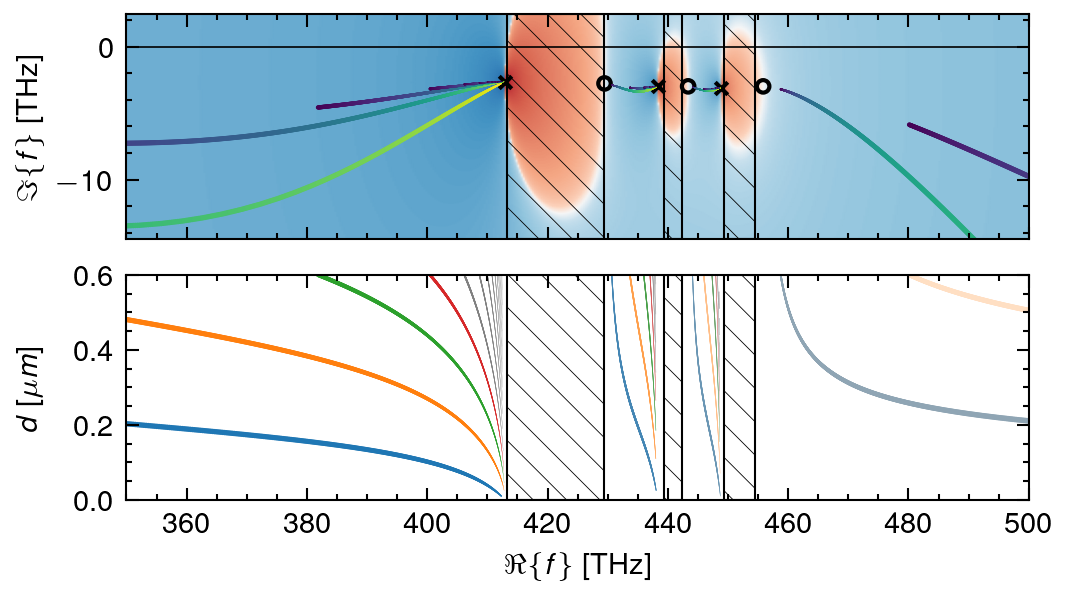

In [ ]:
    plt.figure()
    plot_trajectories(3, 1, 1, domain, unit="THz", plot_neg_eps_r=True, fig_width=90*mm, fig_height=50*mm, cbar=False)
    plt.xlim(350, 500)
    plt.savefig("out/ThreePole.pdf", dpi=1200)

/tmp/ipykernel_151638/311238305.py:73: RuntimeWarning: divide by zero encountered in divide
  s = np.interp(interp_d, thickness, np.abs(res))/(-imag)
/tmp/ipykernel_151638/311238305.py:107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(c_(real), interp_d, c=c, edgecolor='none', s=s, rasterized=True)
/tmp/ipykernel_151638/311238305.py:97: RuntimeWarning: divide by zero encountered in divide
  s = np.interp(interp_d, thickness, np.abs(res))/(-imag)
/tmp/ipykernel_151638/311238305.py:113: RuntimeWarning: divide by zero encountered in divide
  s = np.interp(interp_d, thickness, np.abs(res))/(-imag)


Start Rendering


/home/jd/phd/code/misc/qnm_strong_coupling/.venv/lib/python3.11/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


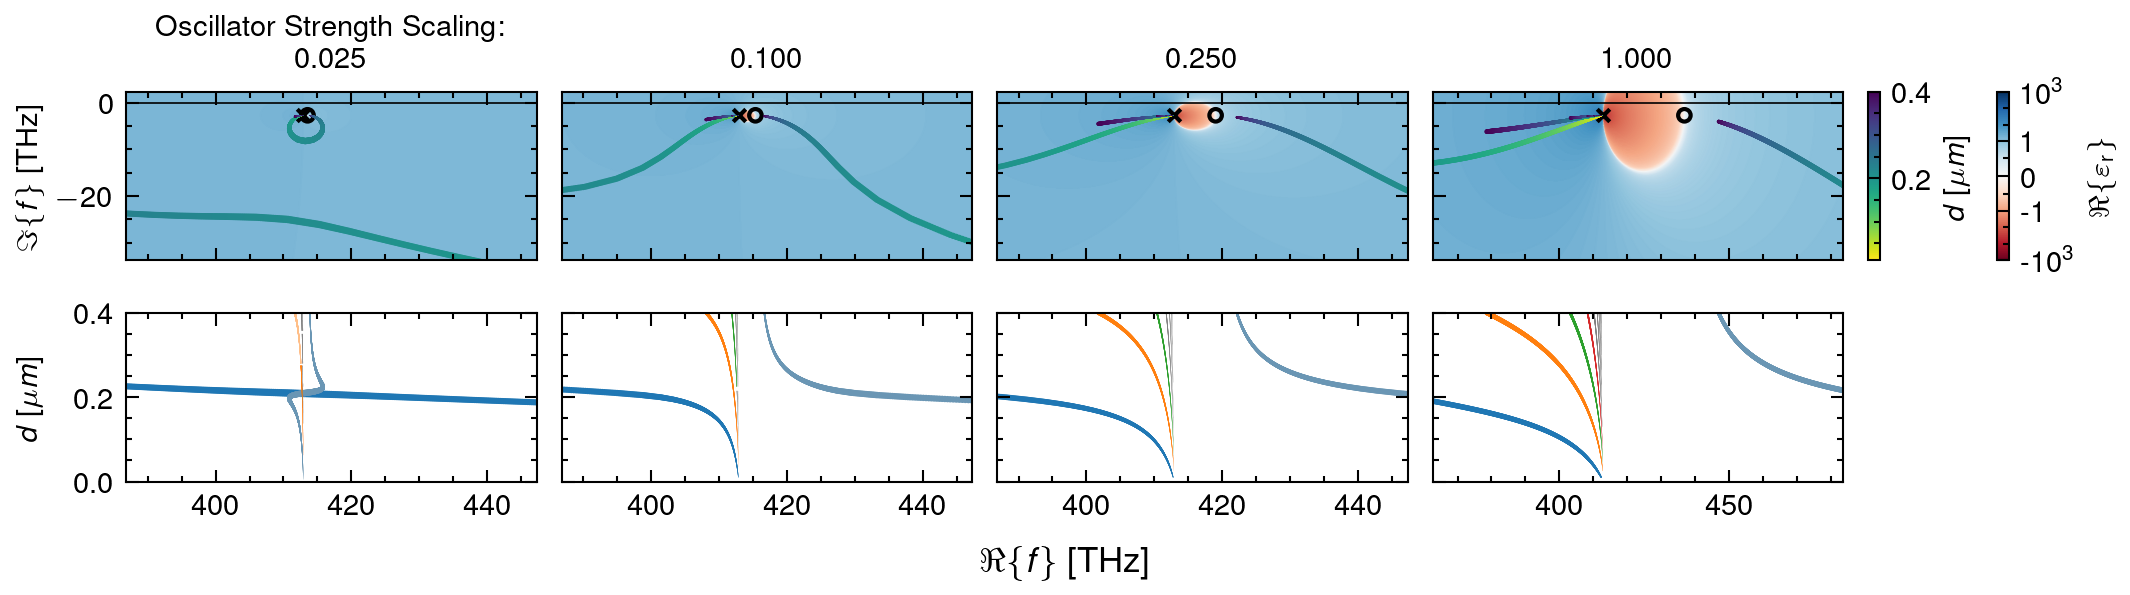

In [50]:
    oscs = [1, 0.25, 0.1, 0.025, 0.01][0:-1]
    plot_domain2 = [1.6-0.14j, 1.85+0.01j]
    plot_domain1 = [1.5-0.14j, 2+0.01j]

    fig, axss = plt.subplots(
        2, len(oscs)+2, sharex="col",
        figsize=(180*mm,50*mm), constrained_layout=True, width_ratios=[1]*len(oscs)+[0.03]*2
        )
    for osc, axs in zip(oscs[::-1], axss.T):
      pcm, cmap, norm = plot_trajectories(
          1, osc, 1, domain, 
          plot_domain=plot_domain1 if osc==1 else plot_domain2, 
          unit="THz", axs=axs, cbar=False, labels=False, d_limit=0.4, upsample=10
      )
      axs[0].set_title(f"{osc:.3f}")


    cb = plt.colorbar( pcm,
      label="$\Re\{\\varepsilon_\mathrm{r}\}$", 
      ticks=[-1e3, -1, 0, 1, 1e3], cax=axss[0, -1]
    )
    cb.set_ticklabels(["-$10^3$", -1, 0, 1, "$10^3$"])
    mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(mappable, cax=axss[0, -2], label=f"$d$ [{um}]")

    axss[0,0].set_title(f"Oscillator Strength Scaling:\n{oscs[-1]}")
    fig.supxlabel("$\Re\{f\}$ [THz]")
    axss[0,0].set_ylabel("$\Im\{f\}$ [THz]")
    axss[1,0].set_ylabel(f"$d$ [{um}]")

    for axs in axss.T[1:-2]:
      axs[0].sharey(axss[0,0])
      axs[0].tick_params(axis='y',labelleft=False)
      axs[1].sharey(axss[1,0])
      axs[1].tick_params(axis='y',labelleft=False)

    axss[1, -1].axis("off")
    axss[1, -2].axis("off")
    print("Start Rendering")
    plt.savefig("out/OscReduction.pdf", dpi=1200)

In [ ]:
    # plot_thickness(3, 1, 1, domain)
    # plot_thickness(3, 1, 1, domain, inv=False)

In [ ]:
    # e_r = np.linspace(1, 2.5, 1200)
    # eps_r = eps_surmof(e_r, 1, 1, 1)
    # plt.plot(e_r, eps_r)